<a href="https://colab.research.google.com/github/neelakandansecse-hue/Navie-program/blob/main/navie_kmp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter the text: fgrdefghtyujhgtfrdeswkjhyujh
Enter the pattern: frd

--- Naive Algorithm ---
Pattern found at positions: [15]
Execution Time: 90093 nanoseconds

--- KMP Algorithm ---
Pattern found at positions: [15]
Execution Time: 73536 nanoseconds

TIME COMPLEXITY
Naive Algorithm Worst Case  : O(n*m)
KMP Algorithm Worst Case    : O(n+m)

KMP Algorithm is faster and more efficient.


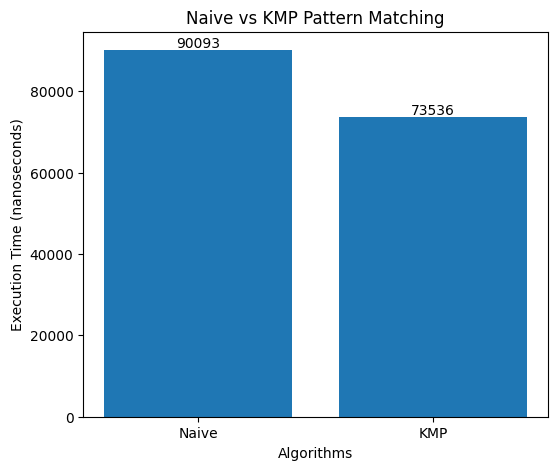

In [1]:
import time
import matplotlib.pyplot as plt

# -----------------------------
# Naive Pattern Matching
# -----------------------------
def naive_search(text, pattern):
    n = len(text)
    m = len(pattern)
    positions = []

    for i in range(n - m + 1):
        j = 0

        while j < m and text[i + j] == pattern[j]:
            j += 1

        if j == m:
            positions.append(i)

    return positions


# -----------------------------
# KMP Algorithm Functions
# -----------------------------
def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m

    length = 0
    i = 1

    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1

    return lps


def kmp_search(text, pattern):
    n = len(text)
    m = len(pattern)

    lps = compute_lps(pattern)

    positions = []

    i = 0
    j = 0

    while i < n:
        if pattern[j] == text[i]:
            i += 1
            j += 1

        if j == m:
            positions.append(i - j)
            j = lps[j - 1]

        elif i < n and pattern[j] != text[i]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return positions


# -----------------------------
# Main Program
# -----------------------------
text = input("Enter the text: ")
pattern = input("Enter the pattern: ")

# Naive Execution Time
start_naive = time.perf_counter_ns()
naive_result = naive_search(text, pattern)
end_naive = time.perf_counter_ns()

naive_time = end_naive - start_naive

# KMP Execution Time
start_kmp = time.perf_counter_ns()
kmp_result = kmp_search(text, pattern)
end_kmp = time.perf_counter_ns()

kmp_time = end_kmp - start_kmp

# Display Results
print("\n--- Naive Algorithm ---")
print("Pattern found at positions:", naive_result)
print("Execution Time:", naive_time, "nanoseconds")

print("\n--- KMP Algorithm ---")
print("Pattern found at positions:", kmp_result)
print("Execution Time:", kmp_time, "nanoseconds")


# -----------------------------
# Time Complexity
# -----------------------------
print("\nTIME COMPLEXITY")
print("Naive Algorithm Worst Case  : O(n*m)")
print("KMP Algorithm Worst Case    : O(n+m)")

# Best Algorithm
if kmp_time < naive_time:
    print("\nKMP Algorithm is faster and more efficient.")
else:
    print("\nNaive Algorithm is faster for this input.")


# -----------------------------
# Bar Graph Comparison
# -----------------------------
algorithms = ['Naive', 'KMP']
times = [naive_time, kmp_time]

plt.figure(figsize=(6, 5))
plt.bar(algorithms, times)

plt.xlabel("Algorithms")
plt.ylabel("Execution Time (nanoseconds)")
plt.title("Naive vs KMP Pattern Matching")

for i, value in enumerate(times):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()